<a href="https://colab.research.google.com/github/weloo11/mnist-image-classifier/blob/main/LinearSVM(HOG)V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (51000, 324)
X_val: (9000, 324)
X_test: (10000, 324)
y_train: (51000,)
y_val: (9000,)
y_test: (10000,)
Epoch 1/60, Loss: 0.206731, Val F1: 0.632716
Epoch 2/60, Loss: 0.120746, Val F1: 0.804938
Epoch 3/60, Loss: 0.092113, Val F1: 0.842214
Epoch 4/60, Loss: 0.078361, Val F1: 0.870588
Epoch 5/60, Loss: 0.071128, Val F1: 0.879610
Epoch 6/60, Loss: 0.065710, Val F1: 0.896742
Epoch 7/60, Loss: 0.063895, Val F1: 0.885745
Epoch 8/60, Loss: 0.061668, Val F1: 0.888889
Epoch 9/60, Loss: 0.058793, Val F1: 0.893781
Epoch 10/60, Loss: 0.056475, Val F1: 0.899723
Epoch 11/60, Loss: 0.059303, Val F1: 0.874329
Epoch 12/60, Loss: 0.055356, Val F1: 0.889373
Epoch 13/60, Loss: 0.054036, Val F1: 0.908888
Epoch 14/60, Loss: 0.052812, Val F1: 0.901939
Epoch 15/60, Loss: 0.052440, Val F1: 0.903728
Epoch 16/60, Loss: 0.051399, Val F1: 0.902832
Epoch 17/60, Loss: 0.051967, Val F1: 0.892291
Epoch 18/60, Loss: 0.050684, Val F1: 0.910714
Epoch 19/60, Loss:

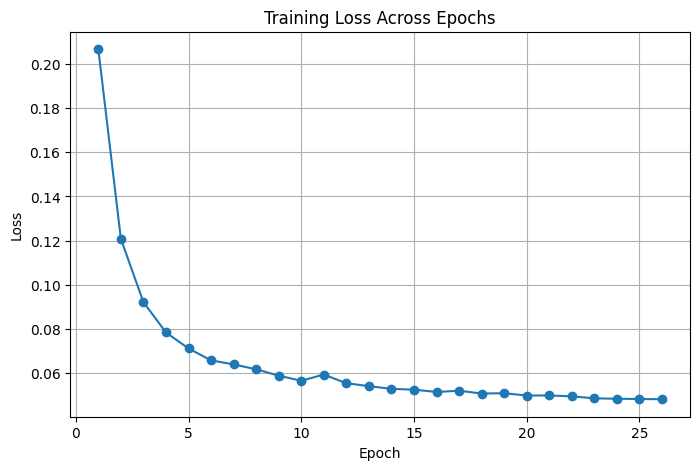

HOG features and labels saved successfully.


In [1]:
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA
from skimage.feature import hog
import matplotlib.pyplot as plt


# ==========================================================
# PREPROCESSING
# ==========================================================

def preprocess_mnist(
    target_digit=5,
    method="hog",
    pca_components=100,
    val_ratio=0.15
):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    y_train = np.where(y_train == target_digit, 1, 0)
    y_test = np.where(y_test == target_digit, 1, 0)

    x_train = x_train.astype(np.float64) / 255.0
    x_test = x_test.astype(np.float64) / 255.0

    np.random.seed(42)
    indices = np.random.permutation(len(x_train))

    x_train = x_train[indices]
    y_train = y_train[indices]

    val_size = int(len(x_train) * val_ratio)

    x_val = x_train[:val_size]
    y_val = y_train[:val_size]

    x_train = x_train[val_size:]
    y_train = y_train[val_size:]

    if method == "flatten":
        X_train = flatten_features(x_train)
        X_val = flatten_features(x_val)
        X_test = flatten_features(x_test)

    elif method == "pca":
        X_train_flat = flatten_features(x_train)
        X_val_flat = flatten_features(x_val)
        X_test_flat = flatten_features(x_test)

        pca = PCA(n_components=pca_components)

        X_train = pca.fit_transform(X_train_flat)
        X_val = pca.transform(X_val_flat)
        X_test = pca.transform(X_test_flat)

        print("PCA variance kept:", round(np.sum(pca.explained_variance_ratio_), 4))

    elif method == "hog":
        X_train = hog_features_dataset(x_train)
        X_val = hog_features_dataset(x_val)
        X_test = hog_features_dataset(x_test)

    else:
        raise ValueError("method must be 'flatten', 'pca', or 'hog'")

    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0) + 1e-8

    X_train = (X_train - mean) / std
    X_val = (X_val - mean) / std
    X_test = (X_test - mean) / std

    return X_train, y_train, X_val, y_val, X_test, y_test


def flatten_features(images):
    return images.reshape(images.shape[0], -1)


def hog_single_image(image):
    return hog(
        image,
        orientations=9,
        pixels_per_cell=(7, 7),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )


def hog_features_dataset(images):
    features = []

    for i in range(images.shape[0]):
        features.append(hog_single_image(images[i]))

    return np.array(features)


# ==========================================================
# MANUAL METRICS
# ==========================================================

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([[tn, fp],
                     [fn, tp]])


def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)


def precision_score_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))

    if tp + fp == 0:
        return 0.0

    return tp / (tp + fp)


def recall_score_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    if tp + fn == 0:
        return 0.0

    return tp / (tp + fn)


def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)


def print_metrics(name, y_true, y_pred):
    print(f"\n===== {name} RESULTS =====")
    print("Accuracy :", accuracy_score_manual(y_true, y_pred))
    print("Precision:", precision_score_manual(y_true, y_pred))
    print("Recall   :", recall_score_manual(y_true, y_pred))
    print("F1-score :", f1_score_manual(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix_manual(y_true, y_pred))


# ==========================================================
# LINEAR SVM FROM SCRATCH
# ==========================================================

class LinearSVMFromScratch:
    def __init__(
        self,
        learning_rate=0.01,
        lambda_param=0.0005,
        n_epochs=60,
        batch_size=512,
        lr_decay=0.95,
        patience=8
    ):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr_decay = lr_decay
        self.patience = patience

        self.w = None
        self.b = 0.0

        self.train_losses = []
        self.best_w = None
        self.best_b = None
        self.best_f1 = -1.0

    def _compute_class_weights(self, y):
        n_samples = len(y)
        n_pos = np.sum(y == 1)
        n_neg = np.sum(y == -1)

        weight_pos = n_samples / (2 * n_pos)
        weight_neg = n_samples / (2 * n_neg)

        return weight_pos, weight_neg

    def _hinge_loss(self, X, y, weight_pos, weight_neg):
        scores = X @ self.w + self.b
        margins = y * scores

        sample_weights = np.where(y == 1, weight_pos, weight_neg)
        hinge = np.maximum(0, 1 - margins)

        loss = self.lambda_param * np.dot(self.w, self.w) + np.mean(sample_weights * hinge)

        return loss

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0.0

        weight_pos, weight_neg = self._compute_class_weights(y)

        current_lr = self.learning_rate
        no_improve_count = 0

        for epoch in range(self.n_epochs):
            indices = np.random.permutation(n_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                scores = X_batch @ self.w + self.b
                margins = y_batch * scores

                sample_weights = np.where(y_batch == 1, weight_pos, weight_neg)
                active = margins < 1

                if np.any(active):
                    X_active = X_batch[active]
                    y_active = y_batch[active]
                    w_active = sample_weights[active]

                    grad_w_hinge = -np.mean(
                        (w_active * y_active)[:, np.newaxis] * X_active,
                        axis=0
                    )

                    grad_b_hinge = -np.mean(w_active * y_active)

                else:
                    grad_w_hinge = np.zeros_like(self.w)
                    grad_b_hinge = 0.0

                grad_w = 2 * self.lambda_param * self.w + grad_w_hinge
                grad_b = grad_b_hinge

                self.w -= current_lr * grad_w
                self.b -= current_lr * grad_b

            train_loss = self._hinge_loss(X, y, weight_pos, weight_neg)
            self.train_losses.append(train_loss)

            msg = f"Epoch {epoch + 1}/{self.n_epochs}, Loss: {train_loss:.6f}"

            if X_val is not None and y_val is not None:
                val_pred_svm = self.predict(X_val)
                val_pred_binary = np.where(val_pred_svm == 1, 1, 0)
                val_true_binary = np.where(y_val == 1, 1, 0)

                val_f1 = f1_score_manual(val_true_binary, val_pred_binary)

                msg += f", Val F1: {val_f1:.6f}"

                if val_f1 > self.best_f1:
                    self.best_f1 = val_f1
                    self.best_w = self.w.copy()
                    self.best_b = self.b
                    no_improve_count = 0
                else:
                    no_improve_count += 1

                if no_improve_count >= self.patience:
                    print(msg)
                    print("Early stopping triggered.")
                    break

            print(msg)

            current_lr *= self.lr_decay

        if self.best_w is not None:
            self.w = self.best_w
            self.b = self.best_b

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)

    def predict_with_threshold(self, X, threshold=0.0):
        scores = self.decision_function(X)
        return np.where(scores >= threshold, 1, -1)


# ==========================================================
# RUN HOG + LINEAR SVM
# ==========================================================

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_mnist(
    target_digit=5,
    method="hog",
    pca_components=100,
    val_ratio=0.15
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

y_train_svm = np.where(y_train == 1, 1, -1)
y_val_svm = np.where(y_val == 1, 1, -1)
y_test_svm = np.where(y_test == 1, 1, -1)

svm_model = LinearSVMFromScratch(
    learning_rate=0.01,
    lambda_param=0.0005,
    n_epochs=60,
    batch_size=512,
    lr_decay=0.95,
    patience=8
)

svm_model.fit(
    X_train,
    y_train_svm,
    X_val=X_val,
    y_val=y_val_svm
)


# ==========================================================
# THRESHOLD TUNING
# ==========================================================

thresholds = [-0.5, -0.2, 0.0, 0.2, 0.5, 1.0]

best_threshold = 0.0
best_f1 = -1.0

print("\n===== THRESHOLD TUNING =====")

for threshold in thresholds:
    val_pred_svm = svm_model.predict_with_threshold(X_val, threshold=threshold)
    val_pred = np.where(val_pred_svm == 1, 1, 0)

    f1 = f1_score_manual(y_val, val_pred)

    print(f"Threshold {threshold}: F1 = {f1:.6f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)


# ==========================================================
# FINAL EVALUATION
# ==========================================================

val_pred_svm = svm_model.predict_with_threshold(X_val, threshold=best_threshold)
val_pred = np.where(val_pred_svm == 1, 1, 0)

test_pred_svm = svm_model.predict_with_threshold(X_test, threshold=best_threshold)
test_pred = np.where(test_pred_svm == 1, 1, 0)

print_metrics("VALIDATION", y_val, val_pred)
print_metrics("TEST", y_test, test_pred)


# ==========================================================
# PLOT LOSS
# ==========================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(svm_model.train_losses) + 1), svm_model.train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Epochs")
plt.grid(True)
plt.show()


# ==========================================================
# SAVE PREPROCESSED DATA
# ==========================================================

np.save("X_train_hog.npy", X_train)
np.save("X_val_hog.npy", X_val)
np.save("X_test_hog.npy", X_test)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("HOG features and labels saved successfully.")